# Bab 1: Import Library dan Konfigurasi Path

In [ ]:
import os
import random
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Rescaling, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Konfigurasi Parameter Sesuai Request
DATASET_DIR = Path("Dataset")
TARGET_WIDTH = 256
TARGET_HEIGHT = 256
BATCH_SIZE = 16
EPOCHS = 20
SPLIT_RATIO = 0.2
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Deteksi nama kelas di folder dataset
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if (DATASET_DIR / d).is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}

print("Kelas ditemukan:", CLASS_NAMES)
print("Jumlah kelas   :", NUM_CLASSES)

Kelas ditemukan: ['100k', '10k', '20k', '2k', '50k', '5k']
Jumlah kelas   : 6


# Bab 2: Fungsi Preprocessing

In [ ]:
def mask_hsv(image_bgr, gray_threshold=25, min_area_ratio=0.01, kernel_size=7):
    if image_bgr is None:
        raise ValueError("Gambar tidak berhasil dibaca.")

    work_img = image_bgr.copy()
    gray = cv2.cvtColor(work_img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    h, w = mask.shape
    flood = mask.copy()
    flood_mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(flood, flood_mask, (0, 0), 255)

    flood_inv = cv2.bitwise_not(flood)
    mask = mask | flood_inv

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    refined = np.zeros_like(mask)

    if num_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]
        largest_idx = 1 + np.argmax(areas)
        largest_area = stats[largest_idx, cv2.CC_STAT_AREA]
        min_area = int(min_area_ratio * h * w)

        if largest_area >= min_area:
            refined[labels == largest_idx] = 255
        else:
            refined = mask.copy()
    else:
        refined = mask.copy()

    result = cv2.bitwise_and(work_img, work_img, mask=refined)
    return work_img, refined, result

def crop_to_mask(image_bgr, mask, pad_ratio=0.05):
    coords = cv2.findNonZero(mask)
    if coords is None:
        return image_bgr

    x, y, w, h = cv2.boundingRect(coords)
    h_img, w_img = image_bgr.shape[:2]
    pad = int(max(w, h) * pad_ratio)

    x1 = max(x - pad, 0)
    y1 = max(y - pad, 0)
    x2 = min(x + w + pad, w_img)
    y2 = min(y + h + pad, h_img)

    return image_bgr[y1:y2, x1:x2]

def resize(image_bgr, target_width, target_height, fill_value=0):
    h, w = image_bgr.shape[:2]
    scale = min(target_width / w, target_height / h)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    resized = cv2.resize(image_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    output = np.full((target_height, target_width, 3), fill_value, dtype=np.uint8)

    x_offset = (target_width - new_w) // 2
    y_offset = (target_height - new_h) // 2
    output[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
    return output

def normalize_minmax(image_bgr):
    return image_bgr.astype(np.float32) / 255.0

# Bab 3: Looping Pengumpulan Data & Train-Test Split

In [ ]:
list_gambar = []
list_label = []

print("Memulai pembacaan dataset dan eksekusi preprocessing...")

for nama_kelas in CLASS_NAMES:
    class_path = DATASET_DIR / nama_kelas
    indeks_kelas = class_to_idx[nama_kelas]
    
    # Ambil file gambar di dalam folder kelas
    images_in_folder = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))]
    
    for file_img in images_in_folder:
        img_path = class_path / file_img
        img = cv2.imread(str(img_path))
        
        if img is None:
            continue
            
        _, mask, segmented = mask_hsv(img)
        cropped = crop_to_mask(segmented, mask)
        resized = resize(cropped, TARGET_WIDTH, TARGET_HEIGHT)
        
        img_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
        normed = normalize_minmax(img_rgb)
        
        list_gambar.append(normed)
        list_label.append(indeks_kelas)

# Ubah ke tipe array NumPy
X = np.array(list_gambar)
y = np.array(list_label)

# Konversi label ke format One-Hot Encoding Kategori
y_kategori = tf.keras.utils.to_categorical(y, num_classes=NUM_CLASSES)

print(f"Total data sukses diproses: {X.shape[0]} gambar")

# Split dataset menggunakan Train-Test Split (80% Train, 20% Validasi)
X_train, X_val, y_train, y_val = train_test_split(
    X, y_kategori, 
    test_size=SPLIT_RATIO, 
    random_state=RANDOM_SEED, 
    stratify=y
)

print(f"Data Training   : {X_train.shape[0]} gambar")
print(f"Data Validation : {X_val.shape[0]} gambar")

Memulai pembacaan dataset dan eksekusi preprocessing...
Total data sukses diproses: 192 gambar
Data Training   : 153 gambar
Data Validation : 39 gambar


# Bab 4: Pembuatan Model MobileNetV2 & Pelatihan

In [ ]:
tf.keras.backend.clear_session()

base_model = MobileNetV2(input_shape=(TARGET_HEIGHT, TARGET_WIDTH, 3), include_top=False, weights='imagenet')
base_model.trainable = False  

model = Sequential([
    Input(shape=(TARGET_HEIGHT, TARGET_WIDTH, 3)),
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.2),
    RandomZoom(0.1),
    Rescaling(scale=2.0, offset=-1.0),  
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax', dtype='float32')
], name="MobileNetV2")

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "MobileNetV2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 random_flip (RandomFlip)    (None, 256, 256, 3)       0         
                                                                 
 random_rotation (RandomRota  (None, 256, 256, 3)      0         
 tion)                                                           
                                                                 
 random_zoom (RandomZoom)    (None, 256, 256, 3)       0         
                                                                 
 rescaling (Rescaling)       (None, 256, 256, 3)       0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 8, 8, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1
)

model.save('models/MobileNetV2.keras')
print("Model berhasil disimpan di: models/MobileNetV2.keras")

Epoch 1/20
10/10 [==============================] - 6s 166ms/step - loss: 1.9732 - accuracy: 0.2418 - val_loss: 1.4135 - val_accuracy: 0.4615
Epoch 2/20
10/10 [==============================] - 1s 126ms/step - loss: 1.4481 - accuracy: 0.4510 - val_loss: 1.2001 - val_accuracy: 0.7692
Epoch 3/20
10/10 [==============================] - 1s 105ms/step - loss: 1.2625 - accuracy: 0.5163 - val_loss: 0.9701 - val_accuracy: 0.8718
Epoch 4/20
10/10 [==============================] - 2s 185ms/step - loss: 0.9930 - accuracy: 0.6667 - val_loss: 0.8485 - val_accuracy: 0.7692
Epoch 5/20
10/10 [==============================] - 3s 302ms/step - loss: 0.8591 - accuracy: 0.6993 - val_loss: 0.6625 - val_accuracy: 0.9231
Epoch 6/20
10/10 [==============================] - 2s 143ms/step - loss: 0.7183 - accuracy: 0.7712 - val_loss: 0.5474 - val_accuracy: 0.8974
Epoch 7/20
10/10 [==============================] - 1s 95ms/step - loss: 0.6661 - accuracy: 0.7974 - val_loss: 0.5063 - val_accuracy: 0.8974
Epoch 8

# Bab 5: Pembuatan Grafik Hasil & Evaluasi Klasifikasi

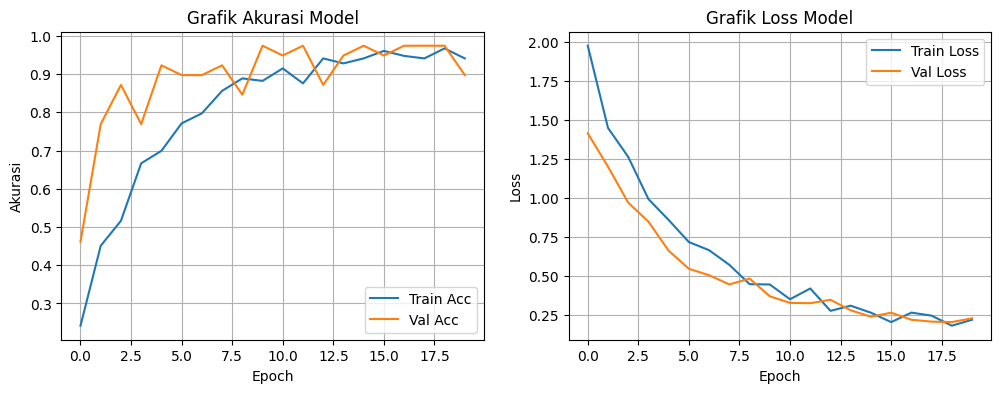

In [ ]:
# Pembuatan grafik Akurasi dan Loss
plt.figure(figsize=(12, 4))

# Subplot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Grafik Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

# Subplot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Grafik Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Prediksi data pengujian untuk divalidasi ke metrik laporan
prediksi = model.predict(X_val, verbose=0)
y_prediksi_kelas = np.argmax(prediksi, axis=1)
y_asli_kelas = np.argmax(y_val, axis=1)

print("\n📊 LAPORAN KLASIFIKASI MODEL:\n")
print(classification_report(y_asli_kelas, y_prediksi_kelas, target_names=CLASS_NAMES, zero_division=0))


📊 LAPORAN KLASIFIKASI MODEL:

              precision    recall  f1-score   support

        100k       1.00      1.00      1.00         6
         10k       0.71      0.83      0.77         6
         20k       1.00      0.71      0.83         7
          2k       0.86      0.86      0.86         7
         50k       1.00      1.00      1.00         7
          5k       0.86      1.00      0.92         6

    accuracy                           0.90        39
   macro avg       0.90      0.90      0.90        39
weighted avg       0.91      0.90      0.90        39



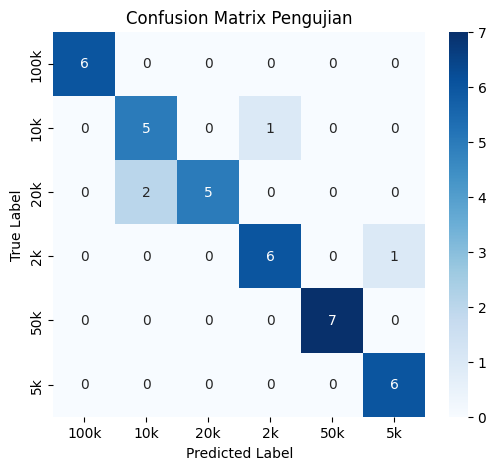

In [ ]:
# Visualisasi Heatmap Confusion Matrix
plt.figure(figsize=(6, 5))
matriks_evaluasi = confusion_matrix(y_asli_kelas, y_prediksi_kelas)
sns.heatmap(matriks_evaluasi, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix Pengujian')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Bab 6: Uji Coba (Demo) Prediksi Gambar Baru

✅ Model berhasil dimuat dari penyimpan lokal!


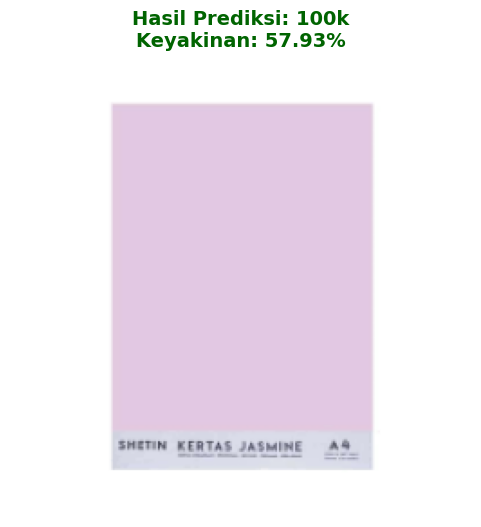

👉 Kesimpulan: Model mendeteksi gambar tersebut sebagai pecahan '100k' (57.93%).


In [ ]:
from tensorflow.keras.models import load_model

PATH_GAMBAR_BARU = "testerKertas.png" 

# 2. Memuat kembali seluruh model yang sudah dilatih sebelumnya
path_model_saved = 'models/MobileNetV2.keras'

if os.path.exists(path_model_saved):
    model_demo = load_model(path_model_saved)
    print("✅ Model berhasil dimuat dari penyimpan lokal!")
else:
    print("❌ File model tidak ditemukan! Pastikan kamu sudah menjalankan Bab 4 sampai selesai.")
    model_demo = None

# Jalankan prediksi jika model dan gambar tersedia
if model_demo is not None:
    # 3. Membaca gambar baru menggunakan OpenCV
    img_bgr_baru = cv2.imread(PATH_GAMBAR_BARU)

    if img_bgr_baru is None:
        print(f"❌ Gagal membaca gambar! Periksa kembali apakah file '{PATH_GAMBAR_BARU}' sudah ada di foldermu.")
    else:
        # 4. Menjalankan fungsi preprocessing aslimu secara berurutan
        _, mask_baru, segmented_baru = mask_hsv(img_bgr_baru)
        cropped_baru = crop_to_mask(segmented_baru, mask_baru)
        resized_baru = resize(cropped_baru, TARGET_WIDTH, TARGET_HEIGHT)
        
        # Konversi warna ke RGB dan normalisasi [0, 1]
        img_rgb_baru = cv2.cvtColor(resized_baru, cv2.COLOR_BGR2RGB)
        normed_baru = normalize_minmax(img_rgb_baru)

        # 5. Mengubah dimensi gambar menjadi (1, 256, 256, 3) agar sesuai input batch model
        input_tensor = np.expand_dims(normed_baru, axis=0)

        # 6. Melakukan prediksi skor kecocokan kelas
        skor_prediksi = model_demo.predict(input_tensor, verbose=0)
        indeks_tertinggi = np.argmax(skor_prediksi, axis=1)[0]
        
        # Ambil nama kelas dan persentase keyakinan model
        nama_prediksi = CLASS_NAMES[indeks_tertinggi]
        persen_keyakinan = skor_prediksi[0][indeks_tertinggi] * 100

        # 7. Menampilkan gambar hasil preprocessing beserta teks hasil tebakan model
        plt.figure(figsize=(6, 6))
        plt.imshow(img_rgb_baru)
        plt.title(f"Hasil Prediksi: {nama_prediksi}\nKeyakinan: {persen_keyakinan:.2f}%", 
                  fontsize=14, fontweight='bold', color='darkgreen')
        plt.axis('off')
        plt.show()

        print(f"👉 Kesimpulan: Model mendeteksi gambar tersebut sebagai pecahan '{nama_prediksi}' ({persen_keyakinan:.2f}%).")